# XGBoost Model Training

# Model 1 (Baseline model)

### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Load processed data

In [2]:
from pathlib import Path
import sys

# Add src as part of the import system also
sys.path.append(str(Path.cwd().parent / 'src'))

from config import PROCESSED_DATA_PATH

df = pd.read_csv(PROCESSED_DATA_PATH / 'processed_data_v1.csv')

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,Name,returns,sma_20,sma_50,...,ema_50,volume_sma,rsi,macd,macd_signal,macd_diff,bb_low,bb_mid,bb_high,target
0,2018-03-14,6.013248,6.024768,5.955650,6.024768,9243600,Maybank,0.000000,5.960257,5.818911,...,5.847915,15862980.0,72.457292,0.064409,0.071062,-0.006654,5.791383,5.960257,6.129131,0
1,2018-03-15,5.967170,6.013248,5.967170,6.013248,12405400,Maybank,-0.007663,5.967745,5.826975,...,5.852592,16166030.0,60.660137,0.057190,0.068288,-0.011098,5.812836,5.967745,6.122654,0
2,2018-03-16,5.944130,5.967170,5.863493,5.898052,21560900,Maybank,-0.003861,5.974081,5.833196,...,5.856182,17244075.0,55.770683,0.049044,0.064439,-0.015395,5.835563,5.974081,6.112599,0
3,2018-03-19,5.944130,5.955650,5.909572,5.932611,7003900,Maybank,0.000000,5.979265,5.839186,...,5.859631,17195960.0,55.770683,0.042103,0.059972,-0.017869,5.854751,5.979265,6.103779,1
4,2018-03-20,5.955650,5.978689,5.909571,5.932611,12778100,Maybank,0.001938,5.985025,5.845407,...,5.863396,17322670.0,57.745645,0.037104,0.055398,-0.018294,5.878137,5.985025,6.091912,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24638 entries, 0 to 24637
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         24638 non-null  str    
 1   Close        24638 non-null  float64
 2   High         24638 non-null  float64
 3   Low          24638 non-null  float64
 4   Open         24638 non-null  float64
 5   Volume       24638 non-null  int64  
 6   Name         24638 non-null  str    
 7   returns      24638 non-null  float64
 8   sma_20       24638 non-null  float64
 9   sma_50       24638 non-null  float64
 10  ema_20       24638 non-null  float64
 11  ema_50       24638 non-null  float64
 12  volume_sma   24638 non-null  float64
 13  rsi          24638 non-null  float64
 14  macd         24638 non-null  float64
 15  macd_signal  24638 non-null  float64
 16  macd_diff    24638 non-null  float64
 17  bb_low       24638 non-null  float64
 18  bb_mid       24638 non-null  float64
 19  bb_high      24

In [5]:
df.isnull().sum()

Date           0
Close          0
High           0
Low            0
Open           0
Volume         0
Name           0
returns        0
sma_20         0
sma_50         0
ema_20         0
ema_50         0
volume_sma     0
rsi            0
macd           0
macd_signal    0
macd_diff      0
bb_low         0
bb_mid         0
bb_high        0
target         0
dtype: int64

In [6]:
df.shape

(24638, 21)

### Time-based Train-Test Split

**Chronologinal split**

In [7]:
# sort the dataset by date
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date').reset_index(drop = True)

df[['Date','Name']].head(20)

,Date,Name
0,2018-03-13,DBS Bank
1,2018-03-13,OCBC Bank
2,2018-03-13,UOB Bank
3,2018-03-14,Maybank
4,2018-03-14,CIMB Group
5,2018-03-14,RHB Bank
6,2018-03-14,Hong Leong Bank
7,2018-03-14,AmBank
8,2018-03-14,DBS Bank
9,2018-03-14,OCBC Bank


*Date increasing, correct*

In [8]:
# Checking class distribution
df['target'].value_counts(normalize = True)

target
0    0.549963
1    0.450037
Name: proportion, dtype: float64

**Class distribution slightly imbalanced.**

**Create walk-forward years**

In [9]:
from config import WALK_FORWARD_START_YEAR

test_years = [year for year in sorted(df['Date'].dt.year.unique()) if year >= WALK_FORWARD_START_YEAR]

test_years

[np.int32(2021),
 np.int32(2022),
 np.int32(2023),
 np.int32(2024),
 np.int32(2025),
 np.int32(2026)]

*Note: Do this to automatically add new years in the future*

**Walk-forward training loop**

In [10]:
from config import FEATURES_v1

results = []

for year in test_years:

    print(f"Testing year: {year}")

    # historical data only
    train_df = df[df['Date'].dt.year < year]

    # current year as unseen data
    test_df = df[df['Date'].dt.year == year]


    X_train = train_df[FEATURES_v1]
    y_train = train_df['target']

    X_test = test_df[FEATURES_v1]
    y_test = test_df['target']


    model = XGBClassifier(n_estimators = 200, learning_rate = 0.05, max_depth = 5, random_state = 42)


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)


    results.append({
        'Test Year': year,
        'Train Samples': len(train_df),
        'Test Samples': len(test_df),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

Testing year: 2021
Testing year: 2022
Testing year: 2023
Testing year: 2024
Testing year: 2025
Testing year: 2026


In [11]:
results_df = pd.DataFrame(results)

results_df

,Test Year,Train Samples,Test Samples,Accuracy,Precision,Recall,F1
0,2021,8310,2964,0.550607,0.479751,0.116755,0.187805
1,2022,11274,2937,0.514811,0.458924,0.237015,0.312590
2,2023,14211,2943,0.547061,0.445361,0.168750,0.244759
3,2024,17154,2979,0.531386,0.546667,0.143256,0.227021
4,2025,20133,2952,0.550474,0.534031,0.295867,0.380775
5,2026,23085,1553,0.534449,0.518000,0.349528,0.417405


In [12]:
results_df.mean(numeric_only = True)

Test Year         2023.500000
Train Samples    15694.500000
Test Samples      2721.333333
Accuracy             0.538132
Precision            0.497122
Recall               0.218529
F1                   0.295059
dtype: float64

**Almost like random guessing :(**

In [13]:
results_df.std(numeric_only = True)

Test Year           1.870829
Train Samples    5526.705085
Test Samples      572.562195
Accuracy            0.014076
Precision           0.041696
Recall              0.091635
F1                  0.090869
dtype: float64

**The model behaves quite consistently**

### Check feature importance

In [14]:
importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})

importance = importance.sort_values(by='Importance', ascending = False)

importance

,Feature,Importance
10,bb_low,0.108656
8,bb_high,0.092736
5,sma_50,0.089041
4,sma_20,0.085595
6,ema_20,0.082675
7,ema_50,0.080965
11,volume_sma,0.080148
12,returns,0.079467
2,macd_signal,0.078999
1,macd,0.078787


**Never use bb_mid, the reason might because of it is highly correlated to SMA_20**

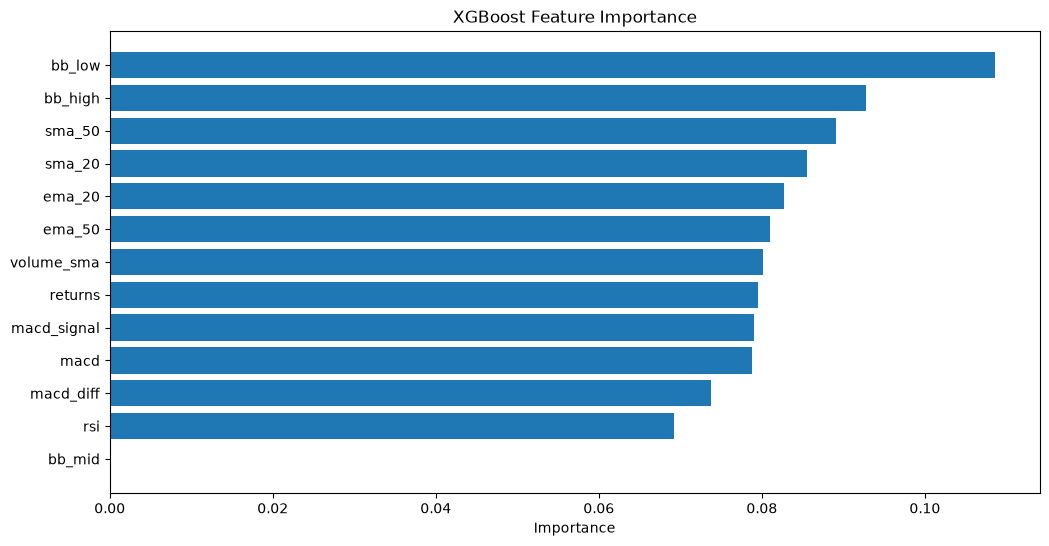

In [15]:
plt.figure(figsize = (12,6))

plt.barh(importance['Feature'], importance['Importance'])

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [16]:
# Save results for comparisons later
model1_summary = {
    "Model": "XGBoost Baseline",
    "Accuracy": results_df["Accuracy"].mean(),
    "Precision": results_df["Precision"].mean(),
    "Recall": results_df["Recall"].mean(),
    "F1": results_df["F1"].mean()
}

pd.DataFrame([model1_summary])

,Model,Accuracy,Precision,Recall,F1
0,XGBoost Baseline,0.538132,0.497122,0.218529,0.295059


# Model 2 (Add features)

In [17]:
from config import PROCESSED_DATA_PATH

df2 = pd.read_csv(PROCESSED_DATA_PATH / 'processed_data_v2.csv')

df2.shape

(24519, 28)

**Few new features added.**

In [18]:
df2.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Name', 'returns',
       'sma_20', 'sma_50', 'ema_20', 'ema_50', 'volume_sma', 'rsi', 'macd',
       'macd_signal', 'macd_diff', 'bb_low', 'bb_mid', 'bb_high',
       'returns_lag_1', 'returns_lag_3', 'returns_lag_5', 'volatility_10',
       'volatility_20', 'daily_range', 'volume_change', 'target'],
      dtype='str')

In [19]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 24519 entries, 0 to 24518
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           24519 non-null  str    
 1   Close          24519 non-null  float64
 2   High           24519 non-null  float64
 3   Low            24519 non-null  float64
 4   Open           24519 non-null  float64
 5   Volume         24519 non-null  int64  
 6   Name           24519 non-null  str    
 7   returns        24519 non-null  float64
 8   sma_20         24519 non-null  float64
 9   sma_50         24519 non-null  float64
 10  ema_20         24519 non-null  float64
 11  ema_50         24519 non-null  float64
 12  volume_sma     24519 non-null  float64
 13  rsi            24519 non-null  float64
 14  macd           24519 non-null  float64
 15  macd_signal    24519 non-null  float64
 16  macd_diff      24519 non-null  float64
 17  bb_low         24519 non-null  float64
 18  bb_mid         24

In [20]:
df2.isna().sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Name             0
returns          0
sma_20           0
sma_50           0
ema_20           0
ema_50           0
volume_sma       0
rsi              0
macd             0
macd_signal      0
macd_diff        0
bb_low           0
bb_mid           0
bb_high          0
returns_lag_1    0
returns_lag_3    0
returns_lag_5    0
volatility_10    0
volatility_20    0
daily_range      0
volume_change    0
target           0
dtype: int64

**Dataset looks good**

### Time-based Train-Test Split

**Chronologinal split**

In [21]:
# sort the dataset by date
df2['Date'] = pd.to_datetime(df2['Date'])

df2 = df2.sort_values('Date').reset_index(drop = True)

df2[['Date','Name']].head(20)

,Date,Name
0,2018-03-13,DBS Bank
1,2018-03-13,OCBC Bank
2,2018-03-13,UOB Bank
3,2018-03-14,Maybank
4,2018-03-14,CIMB Group
5,2018-03-14,RHB Bank
6,2018-03-14,Hong Leong Bank
7,2018-03-14,AmBank
8,2018-03-14,DBS Bank
9,2018-03-14,OCBC Bank


**Check target distribution**

In [22]:
df2['target'].value_counts(normalize = True)

target
0    0.550553
1    0.449447
Name: proportion, dtype: float64

**Still slightly imbalanced**

**Walk-forward training loop**

In [23]:
from config import FEATURES_v2

results = []

for year in test_years:

    print(f"Testing year: {year}")

    # historical data only
    train_df = df2[df2['Date'].dt.year < year]

    # current year as unseen data
    test_df = df2[df2['Date'].dt.year == year]


    X_train = train_df[FEATURES_v2]
    y_train = train_df['target']

    X_test = test_df[FEATURES_v2]
    y_test = test_df['target']


    model = XGBClassifier(n_estimators = 200, learning_rate = 0.05, max_depth = 5, random_state = 42)


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)


    results.append({
        'Test Year': year,
        'Train Samples': len(train_df),
        'Test Samples': len(test_df),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

Testing year: 2021
Testing year: 2022
Testing year: 2023
Testing year: 2024
Testing year: 2025
Testing year: 2026


In [24]:
results_df2 = pd.DataFrame(results)

results_df2

,Test Year,Train Samples,Test Samples,Accuracy,Precision,Recall,F1
0,2021,8245,2952,0.561653,0.520958,0.198479,0.287445
1,2022,11197,2936,0.507834,0.449294,0.256223,0.326340
2,2023,14133,2943,0.556575,0.474438,0.181250,0.262295
3,2024,17076,2977,0.540477,0.574519,0.167133,0.258938
4,2025,20053,2952,0.562669,0.550808,0.345903,0.424944
5,2026,23005,1514,0.542933,0.522772,0.369231,0.432787


In [25]:
results_df2.mean(numeric_only = True)

Test Year         2023.500000
Train Samples    15618.166667
Test Samples      2712.333333
Accuracy             0.545357
Precision            0.515465
Recall               0.253036
F1                   0.332125
dtype: float64

In [26]:
results_df2.std(numeric_only = True)

Test Year           1.870829
Train Samples    5522.216092
Test Samples      587.224886
Accuracy            0.020634
Precision           0.046652
Recall              0.086769
F1                  0.078753
dtype: float64

In [27]:
# Save results for comparisons
model2_summary = {
    "Model": "XGBoost Added Features",
    "Accuracy": results_df2["Accuracy"].mean(),
    "Precision": results_df2["Precision"].mean(),
    "Recall": results_df2["Recall"].mean(),
    "F1": results_df2["F1"].mean()
}

pd.DataFrame([model2_summary])

,Model,Accuracy,Precision,Recall,F1
0,XGBoost Added Features,0.545357,0.515465,0.253036,0.332125


### Model 1 vs Model 2

In [28]:
comparison_df = pd.DataFrame([model1_summary, model2_summary])

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,XGBoost Baseline,0.538132,0.497122,0.218529,0.295059
1,XGBoost Added Features,0.545357,0.515465,0.253036,0.332125


**Accuracy: ↑**
- **IMPROVED**
- New features introduced more valuable context which increased overall correctness

**Precision: ↑**
- **IMPROVED**
- Hits are cleaner, resulting in a higher ratio of true positives to predicted positives

**Recall: ↑**
- **IMPROVED**
- Produces lesser false negatives

**F1: ↑**
- **IMPROVED**
- Provides a better overall balance

#### Comparison between Model 1 & Model 2
Model 1 = more conservative, fewer false alarms, but misses many opportunities due to lower recall

Model 2 = more aggressive and effective, it catches more opportunities and at the same time getting cleaner hits overall.


### Check feature importance

In [29]:
importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})

importance = importance.sort_values(by='Importance', ascending = False)

importance

,Feature,Importance
10,bb_low,0.081826
7,ema_50,0.073476
8,bb_high,0.065440
5,sma_50,0.058183
6,ema_20,0.056918
12,returns,0.053729
11,volume_sma,0.053648
0,rsi,0.049894
2,macd_signal,0.048924
1,macd,0.047492


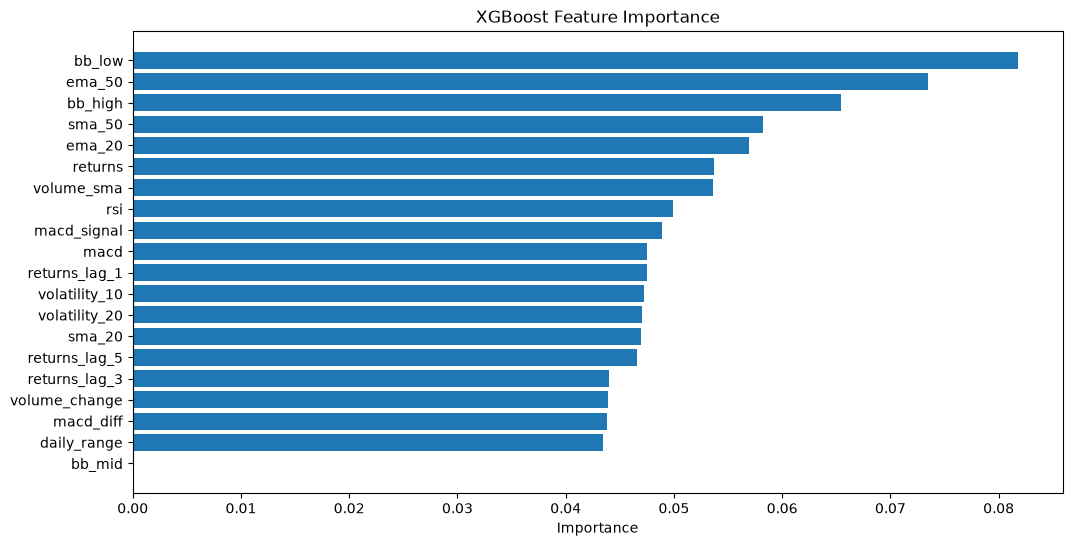

In [30]:
plt.figure(figsize = (12,6))

plt.barh(importance['Feature'], importance['Importance'])

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()